In [32]:
import sys
!{sys.executable} -m pip install pandas matplotlib

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

In [34]:
df = pd.read_csv('data/salesdaily.csv')
df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   str    
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   str    
dtypes: float64(8), int64(3), str(2)
memory usage: 214.0 KB


In [36]:
df['datum'] = pd.to_datetime(df['datum'], format='%m/%d/%Y')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datum         2106 non-null   datetime64[us]
 1   M01AB         2106 non-null   float64       
 2   M01AE         2106 non-null   float64       
 3   N02BA         2106 non-null   float64       
 4   N02BE         2106 non-null   float64       
 5   N05B          2106 non-null   float64       
 6   N05C          2106 non-null   float64       
 7   R03           2106 non-null   float64       
 8   R06           2106 non-null   float64       
 9   Year          2106 non-null   int64         
 10  Month         2106 non-null   int64         
 11  Hour          2106 non-null   int64         
 12  Weekday Name  2106 non-null   str           
dtypes: datetime64[us](1), float64(8), int64(3), str(1)
memory usage: 214.0 KB


In [ ]:
#Q1 TOTAL SALES QUANTITIES
category_totals = df[['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']].sum()
category_totals

M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
N02BE    63005.402708
N05B     18645.737500
N05C      1249.958333
R03      11608.822917
R06       6107.817500
dtype: float64

In [ ]:
#Q2 HIGHEST 3 TOTAL SALES
category_totals.sort_values(ascending=False).head(3)

N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
dtype: float64

In [ ]:
#Q3 HIGHEST SALE 01/2015, 06/2016, 09/2017
def top_three(year, month):
    filtered = df[(df['Year'] == year) & (df['Month'] == month)]
    totals = filtered[['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']].sum()
    highest_sales = totals.sort_values(ascending=False).head(3)
    print(f'Top 3 for {month}/{year}:')
    print(highest_sales, '\n')

print(top_three(2015, 1))
print(top_three(2016, 7))
print(top_three(2017, 9))



Top 3 for 1/2015:
N02BE    1044.24
N05B      463.00
R03       177.25
dtype: float64 

None
Top 3 for 7/2016:
N02BE    652.362000
N05B     240.000000
M01AB    194.528333
dtype: float64 

None
Top 3 for 9/2017:
N02BE    863.75
N05B     223.00
R03      139.00
dtype: float64 

None


In [ ]:
#Q4 MOST SOLD IN 2017
def top_year(year):
    filtered = df[df['Year'] == year]
    totals = filtered[['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']].sum()
    top = totals.sort_values(ascending=False).head(1)
    print(f'Top selling category in {year}:\n{top}')

top_year(2017)

Top selling category in 2017:
N02BE    9258.804833
dtype: float64


In [ ]:
#Q5 DRUG CATEGORY WITH HIGHEST AVERAGE DAILY SALES
category_averages = df[['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']].mean()
category_averages.sort_values(ascending=False).head(1)

N02BE    29.917095
dtype: float64

In [ ]:
#Q6 IS R03 SOLD MORE DURING SPECIFIC MONTHS
df.groupby('Month')['R03'].mean().sort_values(ascending=False)

Month
12    7.916129
10    7.208589
2     6.896943
1     6.835980
3     6.290323
11    6.226667
4     5.771528
5     5.006944
9     4.402315
6     4.350000
8     3.102151
7     2.956989
Name: R03, dtype: float64

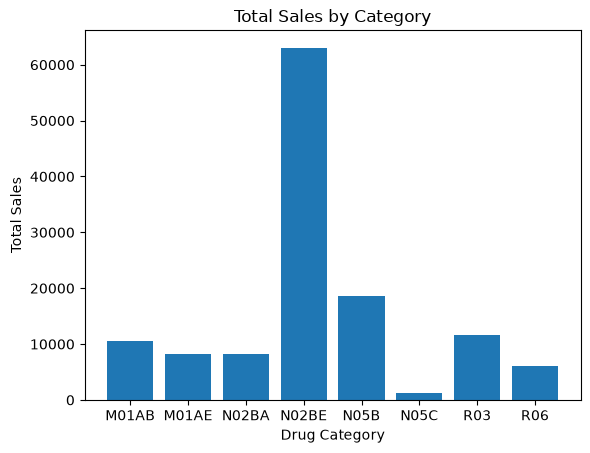

In [46]:
#q1 graphing using matplotlib
plt.bar(category_totals.index, category_totals.values)
plt.title('Total Sales by Category')
plt.xlabel('Drug Category')
plt.ylabel('Total Sales')
plt.show()

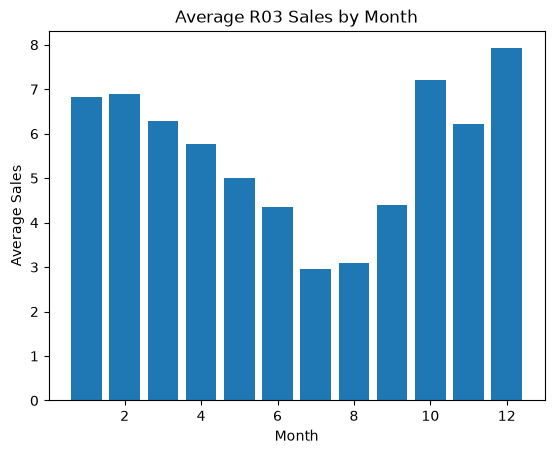

In [48]:
#Q6 GRAPHING USING MATPLOTLIB
monthly_r03 = df.groupby('Month')['R03'].mean()

plt.bar(monthly_r03.index, monthly_r03.values)
plt.title('Average R03 Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.show()